In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

df_read= pd.read_csv("student_performance_updated_1000.csv")

In [36]:
df = df_read.copy()

In [37]:
# ---- 1. Hibás értékek javítása ----

df["AttendanceRate"] = df["AttendanceRate"].clip(lower=0, upper=100)
df["StudyHoursPerWeek"] = df["StudyHoursPerWeek"].clip(lower=0)
df["Study Hours"] = df["Study Hours"].clip(lower=0)
df["Attendance (%)"] = df["Attendance (%)"].clip(lower=0, upper=100)


# ---- 2. Hiányzó értékek kezelése ----

# numerikus oszlopok
num_cols = ["AttendanceRate", "StudyHoursPerWeek", "PreviousGrade",
            "ExtracurricularActivities", "FinalGrade",
            "Study Hours", "Attendance (%)"]

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
# median oszloponként számolva


# kategóriák
cat_cols = ["Name", "Gender", "ParentalSupport", "Online Classes Taken"]


df[cat_cols] = (
    df[cat_cols]
    .fillna(df[cat_cols].mode().iloc[0])
    .astype("object")
)

# duplikátumok eltávolítása
df = df.drop_duplicates(subset="StudentID", keep="first")


C:\Users\berekmerib\AppData\Local\Temp\ipykernel_25864\1948878850.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(df[cat_cols].mode().iloc[0])


In [38]:
# ---- 3. Kategóriák encodolása ----

# Gender: Male/Female -> 0/1
gender_map = {"Male": 0, "Female": 1}
df.loc[:, "Gender"] = df["Gender"].map(gender_map)

# ParentalSupport: Low/Medium/High -> 0/1/2
parental_map = {"Low": 0, "Medium": 1, "High": 2}
df.loc[:, "ParentalSupport"] = df["ParentalSupport"].map(parental_map)

online_map = {True: 1, False: 0, "Yes": 1, "No": 0}
df.loc[:, "Online Classes Taken"] = df["Online Classes Taken"].map(online_map)
df.loc[:, "Online Classes Taken"] = pd.to_numeric(df["Online Classes Taken"], errors='coerce')
# ha maradt NaN az Online Classes Taken-ben, töltsük 0-val
df.loc[:, "Online Classes Taken"] = df["Online Classes Taken"].fillna(0).astype(int)

C:\Users\berekmerib\AppData\Local\Temp\ipykernel_25864\915454832.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[:, "Online Classes Taken"] = df["Online Classes Taken"].fillna(0).astype(int)


In [39]:
# ---- 4. Modellhez fölkészítés ----

# StudentID és Name csak azonosító, nem kell a modellnek
df = df.dropna(subset=["FinalGrade"])
df = df.drop(columns=["ExtracurricularActivities", "Study Hours","StudyHoursPerWeek","Attendance (%)"])

df_model = df.drop(columns=["StudentID", "Name"])

df_model = pd.get_dummies(df_model, drop_first=True)
x = df_model.drop(columns=["FinalGrade"])
y = df_model["FinalGrade"]

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,     
    random_state=42     
)

In [40]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,     
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt", 
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_pred = np.round(y_pred).astype(int)

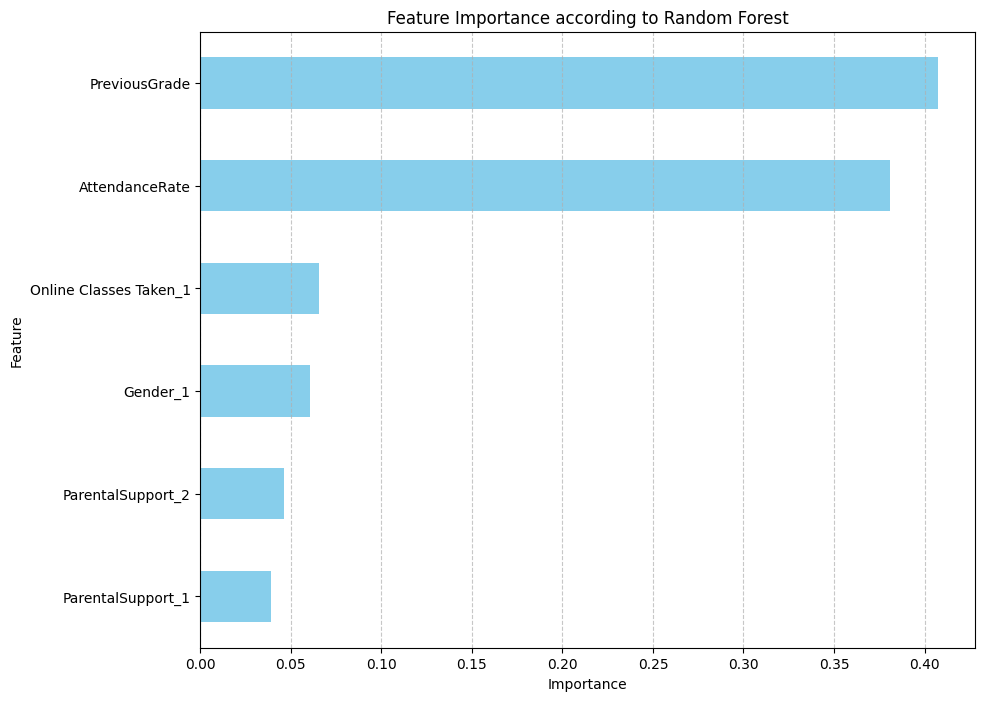

In [41]:
#korreláció vizsgálat
importances = rf.feature_importances_
feature_names = x.columns

fi = pd.Series(importances, index=feature_names).sort_values(ascending=True)
plt.figure(figsize=(10, 8))
fi.plot(kind="barh", color="skyblue")

plt.title("Feature Importance according to Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True, axis="x", linestyle="--", alpha=0.7)
plt.show()

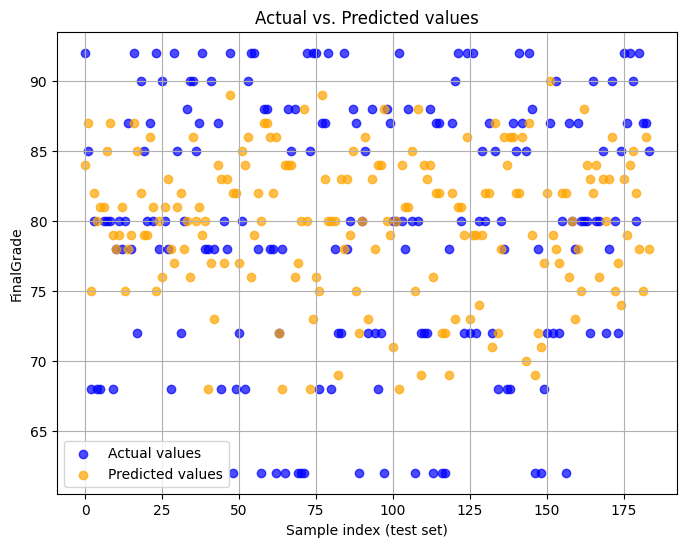

In [42]:
plt.figure(figsize=(8, 6))

plt.scatter(range(len(y_test)), y_test, 
            color="blue", label="Actual values", alpha=0.7)

# Predicted values (shifted slightly to the right for clarity)
plt.scatter(range(len(y_pred)), y_pred, 
            color="orange", label="Predicted values", alpha=0.7)

plt.xlabel("Sample index (test set)")
plt.ylabel("FinalGrade")
plt.title("Actual vs. Predicted values")
plt.legend()
plt.grid(True)
plt.show()

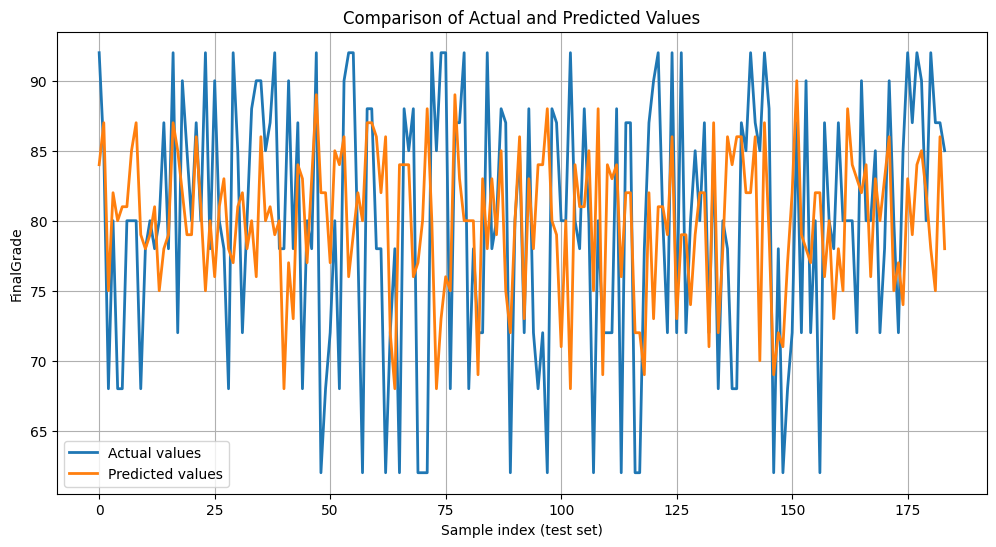

In [43]:
plt.figure(figsize=(12, 6))

plt.plot(y_test.values, label="Actual values", linewidth=2)
plt.plot(y_pred, label="Predicted values", linewidth=2)

plt.xlabel("Sample index (test set)")
plt.ylabel("FinalGrade")
plt.title("Comparison of Actual and Predicted Values")
plt.legend()
plt.grid(True)
plt.show()

In [44]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R²:", r2)
print("y_test átlaga:", y_test.mean())
print("y_pred átlaga:", y_pred.mean())


MAE: 7.698308994447581
R²: -0.11118003985659852
y_test átlaga: 79.92391304347827
y_pred átlaga: 79.9530465381036


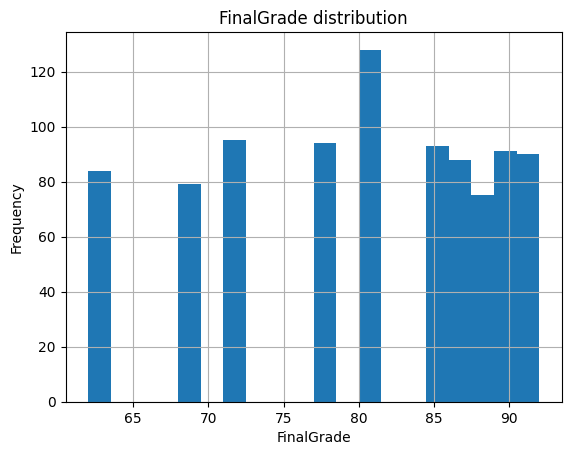

In [45]:
df["FinalGrade"].hist(bins=20)
plt.title("FinalGrade distribution")
plt.xlabel("FinalGrade")
plt.ylabel("Frequency")
plt.show()


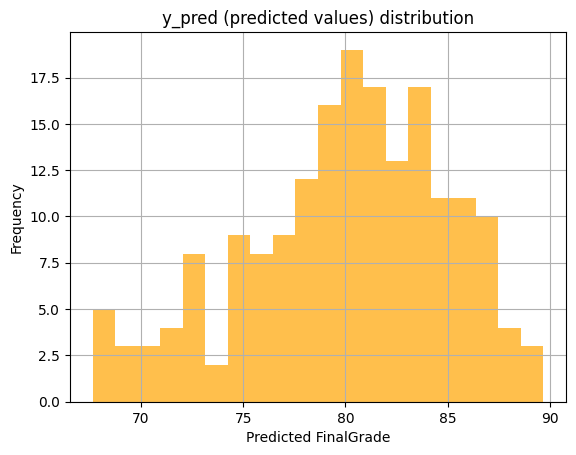

In [46]:
plt.hist(y_pred, bins=20, color="orange", alpha=0.7)
plt.title("y_pred (predicted values) distribution")
plt.xlabel("Predicted FinalGrade")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()